In [1]:
import jax
import jax.numpy as jnp
from jax import random 
print(jax.devices())

import numpy as np
import dill

from lib.lib_ARFF_folds2 import (
    Functions,
    ARFFHyperparameters,
    ARFFTrain,
    nll_loss
)

from lib.plot_lib import PlotResults
PR = PlotResults(Functions)

%load_ext autoreload
%autoreload 2

[CudaDevice(id=0), CudaDevice(id=1), CudaDevice(id=2), CudaDevice(id=3)]


In [2]:
ex_name = "ex8"

# load true functions
with open(f"true_functions/{ex_name}.pkl", "rb") as f:
    true_functions = dill.load(f)

true_drift = true_functions["drift"]
true_diffusion = true_functions["diffusion"]

# load training data
training_data = np.load(f"training_data/{ex_name}.npz")

x = training_data["x_data"]
r = training_data["r_data"]
h = training_data["step_sizes"]
diff_type = str(training_data["diff_type"])
print(x.shape, r.shape, h.shape)

if x.ndim == 3:  # if training data is in trajectory form, take samples to obtain data triplets
    sample_rate = 100
    x = x[:, :, ::sample_rate].reshape(-1, x.shape[1])
    r = r.reshape(r.shape[0], r.shape[1], r.shape[2] // sample_rate, sample_rate).sum(axis=3).reshape(-1, r.shape[1])
    h = h.reshape(h.shape[0], h.shape[1] // sample_rate, sample_rate).sum(axis=2)
    
print(x.shape, r.shape, h.shape)

(100000, 2, 100) (100000, 2, 100) (100000, 100)
(100000, 2) (100000, 2) (100000, 1)


In [3]:
# random_indices = np.random.choice(x.shape[0], 100000, replace=False)
# x = x[random_indices, :]
# r = r[random_indices, :]
# h = h[random_indices, :]

In [13]:
# ARFF parameters
val_split = 0.1
ARFF_val_split = 0.1  # proportion of training data used to test if ARFF has stagnated

drift_hyperparam = ARFFHyperparameters(K=2**7,
                                        M_min=300,
                                        M_max=300,
                                        lambda_reg=1e-3,
                                        gamma=1,
                                        delta=0.2,
                                        name='drift')
diff_hyperparam = ARFFHyperparameters(K=drift_hyperparam.K,
                                       M_min=drift_hyperparam.M_min,
                                       M_max=drift_hyperparam.M_max,
                                       lambda_reg=drift_hyperparam.lambda_reg,
                                       gamma=drift_hyperparam.gamma,
                                       delta=drift_hyperparam.delta,
                                       name='diffusion')


drift epoch: 299


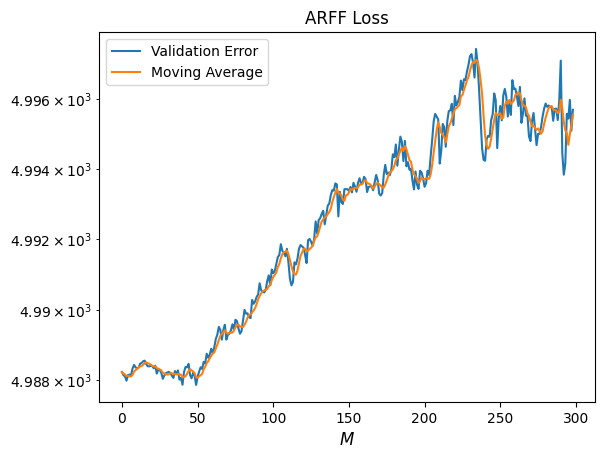

diffusion epoch: 299


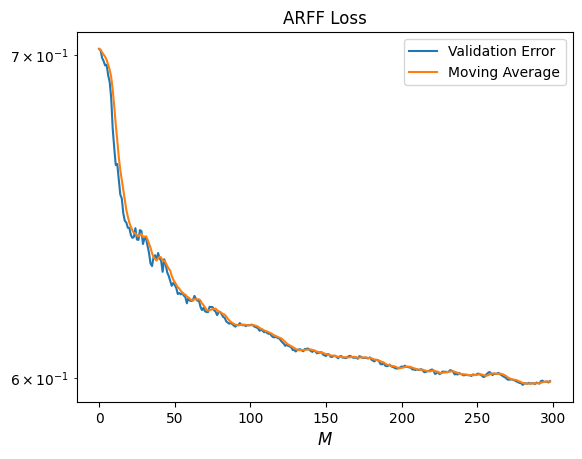

[[ 0.0546552   0.939207  ]
 [-0.00326364  1.0437356 ]
 [ 0.18692075  0.72923714]
 ...
 [-0.02154241  1.1175953 ]
 [-0.08423193  1.1446009 ]
 [ 0.00535694  1.0234007 ]]
[[ 0.28957072  0.7220516 ]
 [-0.01560028  0.98725474]
 [ 0.43787292  0.6028621 ]
 ...
 [ 0.04672504  1.0300974 ]
 [-0.05421735  1.0920174 ]
 [ 0.09315237  0.9277718 ]]
loss = -2327692032.0000, val_loss = 2138798.5000, train_viol_rate = 0.4430, val_viol_rate = 0.4477, time = 6.6308s
drift_err = 3.6294e+00, diff_err = 2.0762e-01


In [14]:
# train model
key = random.PRNGKey(0)
ARFF = ARFFTrain(resampling=False, metropolis_test=True)
 
drift_param, diff_param, time, loss, val_loss, drift_err, diff_err, z, Sigma = ARFF.train_model(key, drift_hyperparam, diff_hyperparam, x, r, h, val_split=val_split, ARFF_val_split=ARFF_val_split, diff_type=diff_type, plot=True, true_drift=true_drift, true_diffusion=true_diffusion, n_folds=1, enforce_spd=True)


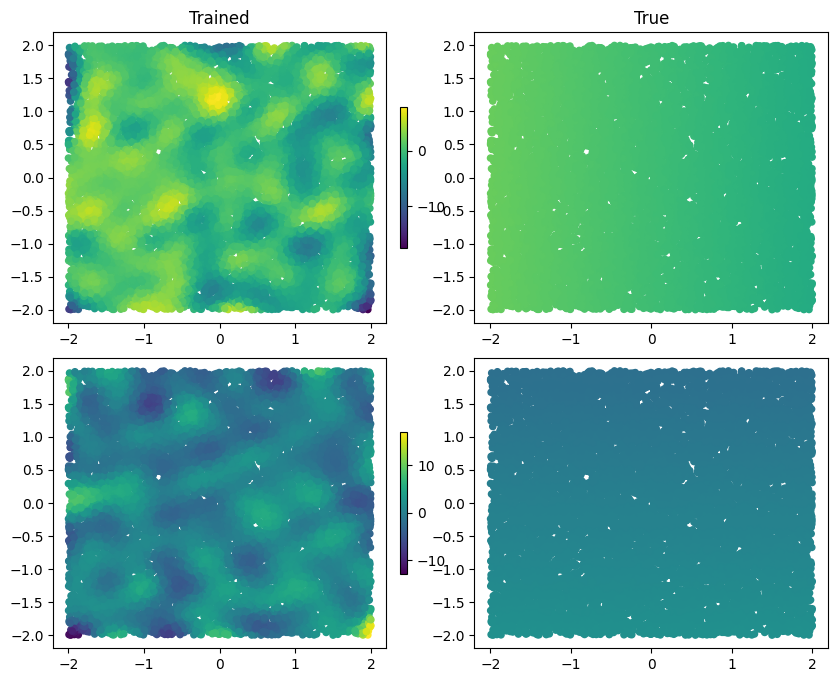

[[ 0.46653193  0.55448174]
 [ 0.40497407  0.58735013]
 [-0.05462835  0.9551656 ]
 ...
 [ 0.00479403  0.9363673 ]
 [ 0.40565374  0.61316264]
 [-0.00543972  0.98298806]]


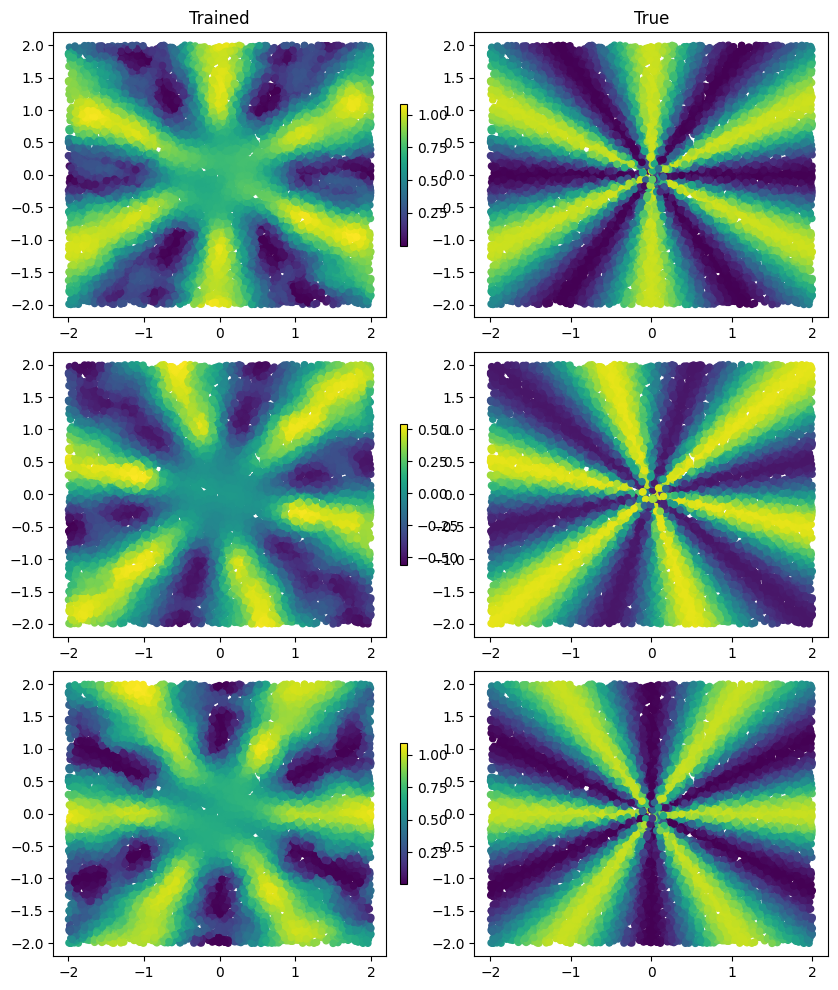

In [15]:
# figures to compare network and true functions
x_plot = x[np.random.choice(x.shape[0], 10000, replace=False), :]

PR.plot_train_v_true(drift_param, x_plot, true_func=true_drift)
PR.plot_train_v_true(diff_param, x_plot, diff_type=diff_type, true_func=true_diffusion)

In [12]:

#np.savez(f"saved_results/NN_param/{ex_name}_ARFF.npz", drift_param=drift_param, diff_param=diff_param, diff_type=diff_type)


In [13]:
# train model
No_Exp = 10
training_time = np.zeros(No_Exp)
loss = np.zeros(No_Exp)
val_loss = np.zeros(No_Exp)

for i in range(No_Exp):
    # jax.clear_caches()  # reset compilations to include compilation time

    key = random.PRNGKey(i+1)
    key1, key2 = random.split(key, 2)

    idx = jax.random.permutation(key1, x.shape[0])
    x_ = x[idx]
    r_ = r[idx]
    h_ = h[idx]

    _, _, training_time[i], loss[i], val_loss[i], _, _ = ARFF.train_model(key2, drift_hyperparam, diff_hyperparam, x_, r_, h_, val_split=val_split, ARFF_val_split=ARFF_val_split, diff_type=diff_type, plot=False)

 

drift epoch: 33
diffusion epoch: 20
loss = -3.2541, val_loss = -3.2371, time = 0.3313s
drift epoch: 20
diffusion epoch: 20
loss = -3.2500, val_loss = -3.2275, time = 0.2104s
drift epoch: 21
diffusion epoch: 20
loss = -3.2447, val_loss = -3.2642, time = 0.2172s
drift epoch: 25
diffusion epoch: 20
loss = -3.2517, val_loss = -3.2674, time = 0.2194s
drift epoch: 26
diffusion epoch: 20
loss = -3.2563, val_loss = -3.2213, time = 0.2264s
drift epoch: 20
diffusion epoch: 20
loss = -3.2493, val_loss = -3.2315, time = 0.1894s
drift epoch: 24
diffusion epoch: 20
loss = -3.2516, val_loss = -3.2619, time = 0.2169s
drift epoch: 33
diffusion epoch: 22
loss = -3.2620, val_loss = -3.1642, time = 0.2706s
drift epoch: 26
diffusion epoch: 20
loss = -3.2531, val_loss = -3.2540, time = 0.2203s
drift epoch: 42
diffusion epoch: 20
loss = -3.2488, val_loss = -3.2945, time = 0.3100s


In [14]:

#np.savez(f"saved_results/loss_time_data/raw_loss_data/{ex_name}_ARFF.npz", val_loss=val_loss, training_time=training_time)
